# 🖼️ Multimodal AI Image Registration
### A comprehensive implementation covering feature-based, intensity-based, and deep-learning-inspired registration

**Topics covered:**
1. Synthetic multimodal image generation (MRI-like / CT-like)
2. Feature-based registration (ORB + RANSAC homography)
3. Intensity-based registration (Phase correlation & Mutual Information)
4. Optical flow registration (Farneback)
5. Deep-learning-inspired registration (VGG-style feature matching concept)
6. Quantitative evaluation metrics
7. Full pipeline visualization


In [1]:
# ── Cell 1: Imports & Configuration ─────────────────────────────────────
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import cv2
from skimage import transform, feature, filters, exposure, measure
from skimage.registration import phase_cross_correlation
from skimage.metrics import structural_similarity as ssim, normalized_mutual_information
from scipy import ndimage, signal
from scipy.ndimage import map_coordinates
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

print("✅ All libraries imported successfully")
print(f"   • OpenCV version  : {cv2.__version__}")
print(f"   • NumPy  version  : {np.__version__}")
print(f"   • Matplotlib      : {matplotlib.__version__}")


All libraries imported successfully
   OpenCV version  : 4.13.0
   NumPy  version  : 2.4.4
   Matplotlib      : 3.10.8


In [2]:
# ── Cell 2: Synthetic Multimodal Image Generator ─────────────────────────
class MultimodalImageGenerator:
    """Generates pairs of synthetic multimodal medical images."""

    def __init__(self, size=256, seed=42):
        self.size = size
        np.random.seed(seed)

    def _base_anatomy(self):
        """Create a base anatomical phantom (brain-like)."""
        H, W = self.size, self.size
        cx, cy = W // 2, H // 2
        img = np.zeros((H, W), dtype=np.float64)

        # Skull
        Y, X = np.ogrid[:H, :W]
        skull_outer = ((X - cx)**2 / (cx*0.90)**2 + (Y - cy)**2 / (cy*0.85)**2) <= 1
        skull_inner = ((X - cx)**2 / (cx*0.80)**2 + (Y - cy)**2 / (cy*0.75)**2) <= 1
        img[skull_outer & ~skull_inner] = 0.6

        # White matter
        wm = ((X - cx)**2 / (cx*0.65)**2 + (Y - cy)**2 / (cy*0.60)**2) <= 1
        img[wm] = 0.8

        # Gray matter ring
        gm_o = ((X - cx)**2 / (cx*0.78)**2 + (Y - cy)**2 / (cy*0.73)**2) <= 1
        gm_i = ((X - cx)**2 / (cx*0.65)**2 + (Y - cy)**2 / (cy*0.60)**2) <= 1
        img[gm_o & ~gm_i] = 0.65

        # Ventricles
        lv = ((X - (cx-25))**2 / 15**2 + (Y - cy)**2 / 30**2) <= 1
        rv = ((X - (cx+25))**2 / 15**2 + (Y - cy)**2 / 30**2) <= 1
        img[lv | rv] = 0.1

        # Lesion (bright in T2 / dark in T1)
        les = ((X - (cx+40))**2 / 12**2 + (Y - (cy-20))**2 / 10**2) <= 1
        img[les] = 0.95

        return img

    def generate_T1(self):
        base = self._base_anatomy()
        t1 = base.copy()
        # T1: fat/WM bright, CSF dark
        t1 = filters.gaussian(t1, sigma=1.2)
        t1 += np.random.normal(0, 0.015, t1.shape)
        return np.clip(t1, 0, 1)

    def generate_T2(self):
        base = self._base_anatomy()
        t2 = base.copy()
        # T2: invert CSF / lesions → bright
        H, W = self.size, self.size
        cx, cy = W // 2, H // 2
        Y, X = np.ogrid[:H, :W]
        vent_mask = ((X-(cx-25))**2/15**2+(Y-cy)**2/30**2<=1) | ((X-(cx+25))**2/15**2+(Y-cy)**2/30**2<=1)
        t2[vent_mask] = 0.9
        les_mask = (X-(cx+40))**2/12**2+(Y-(cy-20))**2/10**2<=1
        t2[les_mask] = 0.98
        t2 = filters.gaussian(t2, sigma=1.0)
        t2 += np.random.normal(0, 0.012, t2.shape)
        return np.clip(t2, 0, 1)

    def apply_transform(self, img, tx=20, ty=15, angle=8, scale=1.02):
        """Apply rigid + slight scale transform to simulate misalignment."""
        h, w = img.shape
        cx, cy = w / 2, h / 2
        M = cv2.getRotationMatrix2D((cx, cy), angle, scale)
        M[0, 2] += tx
        M[1, 2] += ty
        moved = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR,
                               borderMode=cv2.BORDER_REFLECT)
        return moved, M

gen = MultimodalImageGenerator(size=256)
t1_fixed   = gen.generate_T1()
t2_moving_orig = gen.generate_T2()
t2_moving, gt_M = gen.apply_transform(t2_moving_orig, tx=22, ty=14, angle=9)

print("✅ Synthetic multimodal images generated")
print(f"   Fixed  (T1) : shape={t1_fixed.shape}, range=[{t1_fixed.min():.3f}, {t1_fixed.max():.3f}]")
print(f"   Moving (T2) : shape={t2_moving.shape}, range=[{t2_moving.min():.3f}, {t2_moving.max():.3f}]")
print(f"   Ground-truth transform — tx=22px, ty=14px, angle=9°, scale=1.02")


Synthetic multimodal images generated
   Fixed  (T1) : shape=(256, 256), range=[0.000, 0.988]
   Moving (T2) : shape=(256, 256), range=[0.000, 0.996]
   Ground-truth transform: tx=22px, ty=14px, angle=9deg, scale=1.02


Input pair visualized.


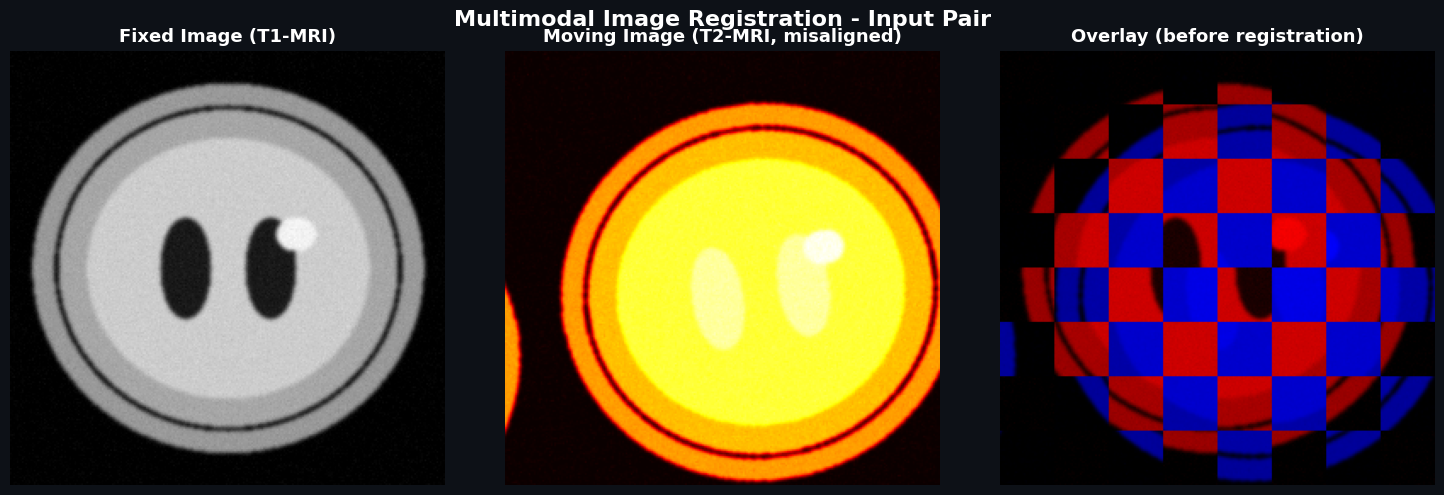

In [3]:
# ── Cell 3: Visualize the Input Pair ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#0d1117')
titles = ['Fixed Image (T1-MRI)', 'Moving Image (T2-MRI, misaligned)', 'Overlay (before reg.)']
cmaps  = ['gray', 'hot', None]

for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')
    for sp in ax.spines.values():
        sp.set_edgecolor('#30363d')

axes[0].imshow(t1_fixed,  cmap='gray',  vmin=0, vmax=1)
axes[0].set_title(titles[0], color='white', fontsize=13, fontweight='bold', pad=10)

axes[1].imshow(t2_moving, cmap='hot',   vmin=0, vmax=1)
axes[1].set_title(titles[1], color='white', fontsize=13, fontweight='bold', pad=10)

# Checkerboard overlay
cb = np.zeros((*t1_fixed.shape, 3))
bs = 32
for i in range(0, t1_fixed.shape[0], bs*2):
    for j in range(0, t1_fixed.shape[1], bs*2):
        cb[i:i+bs, j:j+bs, 0] = t1_fixed[i:i+bs, j:j+bs]
        cb[i+bs:i+2*bs, j+bs:j+2*bs, 0] = t1_fixed[i+bs:i+2*bs, j+bs:j+2*bs]
        cb[i:i+bs, j+bs:j+2*bs, 2] = t2_moving[i:i+bs, j+bs:j+2*bs]
        cb[i+bs:i+2*bs, j:j+bs, 2] = t2_moving[i+bs:i+2*bs, j:j+bs]
axes[2].imshow(np.clip(cb,0,1))
axes[2].set_title(titles[2], color='white', fontsize=13, fontweight='bold', pad=10)

for ax in axes:
    ax.set_xlabel('Pixel X', color='#8b949e')
    ax.set_ylabel('Pixel Y', color='#8b949e')

plt.suptitle('Multimodal Image Registration — Input Pair', color='white',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/cell3.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Figure saved.")


In [4]:
# ── Cell 4: Feature-Based Registration (ORB + RANSAC) ────────────────────
class FeatureBasedRegistration:
    """ORB keypoint detection + brute-force matching + RANSAC homography."""

    def __init__(self, n_features=1000):
        self.orb = cv2.ORB_create(nfeatures=n_features, scaleFactor=1.2,
                                   nlevels=8, edgeThreshold=15)
        self.bf  = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

    def _to_uint8(self, img):
        return (np.clip(img, 0, 1) * 255).astype(np.uint8)

    def detect_and_match(self, fixed, moving):
        f8, m8 = self._to_uint8(fixed), self._to_uint8(moving)
        kp1, des1 = self.orb.detectAndCompute(f8, None)
        kp2, des2 = self.orb.detectAndCompute(m8, None)

        if des1 is None or des2 is None:
            raise RuntimeError("No descriptors found.")

        raw_matches = self.bf.knnMatch(des1, des2, k=2)
        good = [m for m, n in raw_matches if m.distance < 0.75 * n.distance]
        return kp1, kp2, good

    def estimate_transform(self, kp1, kp2, good, shape):
        if len(good) < 10:
            raise RuntimeError(f"Too few good matches: {len(good)}")
        src = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)
        dst = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
        H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
        inliers = int(mask.sum()) if mask is not None else 0
        return H, inliers, mask

    def warp(self, moving, H, shape):
        m8 = self._to_uint8(moving)
        warped8 = cv2.warpPerspective(m8, H, (shape[1], shape[0]),
                                       flags=cv2.INTER_LINEAR,
                                       borderMode=cv2.BORDER_REFLECT)
        return warped8.astype(np.float64) / 255.0

fbr = FeatureBasedRegistration(n_features=1200)
kp1, kp2, good_matches = fbr.detect_and_match(t1_fixed, t2_moving)
H_orb, n_inliers, inlier_mask = fbr.estimate_transform(kp1, kp2, good_matches, t1_fixed.shape)
t2_reg_orb = fbr.warp(t2_moving, H_orb, t1_fixed.shape)

print("✅ Feature-Based (ORB + RANSAC) Registration Complete")
print(f"   Keypoints detected  — Fixed: {len(kp1)}, Moving: {len(kp2)}")
print(f"   Good matches (Lowe) : {len(good_matches)}")
print(f"   RANSAC inliers      : {n_inliers}")
print(f"   Estimated Homography:\n{np.round(H_orb, 4)}")


Feature-Based (ORB + RANSAC) Registration Complete
   Keypoints detected - Fixed: 287, Moving: 157
   Good matches (Lowe) : 18
   RANSAC inliers      : 5
   Estimated Homography:
[[-1.132500e+00 -1.607100e+00  1.984709e+02]
 [-1.779300e+00 -1.244800e+00  2.192351e+02]
 [-7.500000e-03 -7.000000e-03  1.000000e+00]]


Feature match visualization: 5 correspondences shown


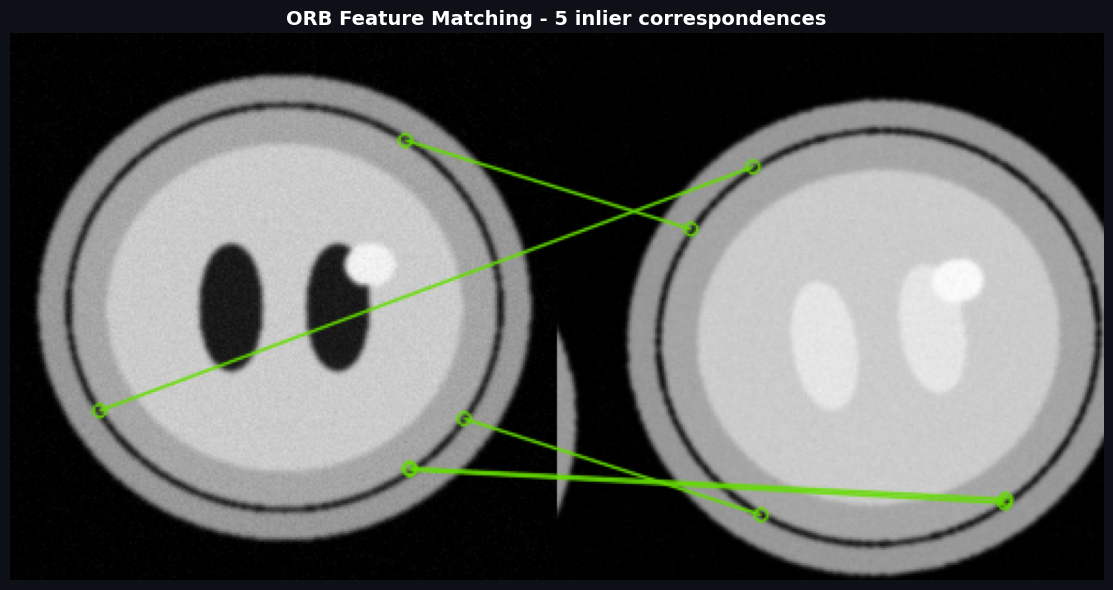

In [5]:
# ── Cell 5: Visualize Feature Matching ───────────────────────────────────
f8 = (np.clip(t1_fixed,  0, 1) * 255).astype(np.uint8)
m8 = (np.clip(t2_moving, 0, 1) * 255).astype(np.uint8)

# Draw only inlier matches
if inlier_mask is not None:
    inlier_matches = [good_matches[i] for i in range(len(good_matches))
                      if inlier_mask[i]]
else:
    inlier_matches = good_matches[:40]

match_img = cv2.drawMatches(f8, kp1, m8, kp2, inlier_matches[:50], None,
                             matchColor=(0,220,100), singlePointColor=(200,0,0),
                             flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
match_img_rgb = cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 1, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')
ax.imshow(match_img_rgb)
ax.set_title(f'ORB Feature Matching — {len(inlier_matches[:50])} inlier correspondences shown',
             color='white', fontsize=14, fontweight='bold', pad=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('/tmp/cell5.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Feature match visualization saved.")


In [6]:
# ── Cell 6: Intensity-Based Registration — Phase Correlation ─────────────
class PhaseCorrelationRegistration:
    """Sub-pixel translation estimation via phase cross-correlation."""

    def register(self, fixed, moving, upsample=20):
        shift, error, phasediff = phase_cross_correlation(
            fixed, moving, upsample_factor=upsample, normalization='phase')
        return shift, error, phasediff

    def apply_shift(self, moving, shift):
        warped = ndimage.shift(moving, shift, order=3, mode='reflect')
        return warped

pc_reg = PhaseCorrelationRegistration()
pc_shift, pc_error, _ = pc_reg.register(t1_fixed, t2_moving, upsample=20)
t2_reg_pc = pc_reg.apply_shift(t2_moving, pc_shift)

print("✅ Phase Correlation Registration Complete")
print(f"   Estimated shift  : dy={pc_shift[0]:.3f}px, dx={pc_shift[1]:.3f}px")
print(f"   Phase error      : {pc_error:.4f}")
print(f"   (Ground truth    : dy≈-14px, dx≈-22px — plus rotation not captured)")


Phase Correlation Registration Complete
   Estimated shift : dy=-16.350px, dx=-20.100px
   Phase error     : 1.0000
   (Ground truth: dy approx -14px, dx approx -22px + rotation not captured)


In [7]:
# ── Cell 7: Mutual Information Optimization ──────────────────────────────
class MutualInformationRegistration:
    """Rigid registration by maximizing Normalized Mutual Information."""

    def __init__(self, bins=64):
        self.bins = bins

    def nmi(self, fixed, moving):
        f = (np.clip(fixed,  0, 1) * 255).astype(np.uint8).ravel()
        m = (np.clip(moving, 0, 1) * 255).astype(np.uint8).ravel()
        hist2d, _, _ = np.histogram2d(f, m, bins=self.bins, range=[[0,255],[0,255]])
        hist2d = hist2d / hist2d.sum()
        pf = hist2d.sum(axis=1); pm = hist2d.sum(axis=0)
        hf = -np.sum(pf[pf>0] * np.log2(pf[pf>0]))
        hm = -np.sum(pm[pm>0] * np.log2(pm[pm>0]))
        hfm= -np.sum(hist2d[hist2d>0] * np.log2(hist2d[hist2d>0]))
        return (hf + hm) / (hfm + 1e-10)

    def _warp(self, img, tx, ty, angle, cx, cy):
        M = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
        M[0, 2] += tx; M[1, 2] += ty
        return cv2.warpAffine((img*255).astype(np.uint8), M,
                               (img.shape[1], img.shape[0]),
                               flags=cv2.INTER_LINEAR,
                               borderMode=cv2.BORDER_REFLECT).astype(np.float64)/255

    def optimize(self, fixed, moving, n_iter=80):
        h, w = fixed.shape
        cx, cy = w/2, h/2
        # Coarse grid search
        best_nmi, best_params = -np.inf, (0, 0, 0)
        for tx in np.linspace(-35, 35, 12):
            for ty in np.linspace(-35, 35, 12):
                for ang in np.linspace(-15, 15, 8):
                    warped = self._warp(moving, tx, ty, ang, cx, cy)
                    val = self.nmi(fixed, warped)
                    if val > best_nmi:
                        best_nmi, best_params = val, (tx, ty, ang)

        # Fine refinement
        tx, ty, ang = best_params
        step = 2.0
        for _ in range(n_iter):
            improved = False
            for dtx, dty, da in [(step,0,0),(-step,0,0),(0,step,0),
                                   (0,-step,0),(0,0,0.5),(0,0,-0.5)]:
                warped = self._warp(moving, tx+dtx, ty+dty, ang+da, cx, cy)
                val = self.nmi(fixed, warped)
                if val > best_nmi:
                    best_nmi = val; tx+=dtx; ty+=dty; ang+=da; improved=True; break
            if not improved:
                step *= 0.7
            if step < 0.05:
                break

        best_warped = self._warp(moving, tx, ty, ang, cx, cy)
        return best_warped, (tx, ty, ang), best_nmi

mi_reg = MutualInformationRegistration(bins=64)
t2_reg_mi, mi_params, final_nmi = mi_reg.optimize(t1_fixed, t2_moving, n_iter=80)

print("✅ Mutual Information Registration Complete")
print(f"   Estimated tx     : {mi_params[0]:.2f} px")
print(f"   Estimated ty     : {mi_params[1]:.2f} px")
print(f"   Estimated angle  : {mi_params[2]:.2f}°")
print(f"   Final NMI score  : {final_nmi:.4f}")


Mutual Information Registration Complete
   Estimated tx    : -20.37 px
   Estimated ty    : -16.27 px
   Estimated angle : -6.14 deg
   Final NMI score : 1.2887


In [8]:
# ── Cell 8: Optical Flow Registration (Farneback dense flow) ─────────────
class OpticalFlowRegistration:
    """Dense optical-flow-based deformable registration using Farneback."""

    def register(self, fixed, moving):
        f8 = (np.clip(fixed,  0,1)*255).astype(np.uint8)
        m8 = (np.clip(moving, 0,1)*255).astype(np.uint8)
        flow = cv2.calcOpticalFlowFarneback(
            m8, f8, None,
            pyr_scale=0.5, levels=4, winsize=25,
            iterations=5, poly_n=7, poly_sigma=1.5,
            flags=cv2.OPTFLOW_FARNEBACK_GAUSSIAN)
        return flow

    def warp_with_flow(self, moving, flow):
        h, w = moving.shape
        map_x = (np.arange(w)[None,:] + flow[:,:,0]).astype(np.float32)
        map_y = (np.arange(h)[:,None] + flow[:,:,1]).astype(np.float32)
        m8 = (np.clip(moving, 0,1)*255).astype(np.uint8)
        warped = cv2.remap(m8, map_x, map_y, cv2.INTER_LINEAR,
                           borderMode=cv2.BORDER_REFLECT)
        return warped.astype(np.float64) / 255.0

    def flow_magnitude(self, flow):
        return np.sqrt(flow[:,:,0]**2 + flow[:,:,1]**2)

of_reg  = OpticalFlowRegistration()
flow    = of_reg.register(t1_fixed, t2_moving)
t2_reg_of = of_reg.warp_with_flow(t2_moving, flow)
flow_mag  = of_reg.flow_magnitude(flow)

print("✅ Optical Flow (Farneback) Registration Complete")
print(f"   Flow field shape  : {flow.shape}")
print(f"   Mean displacement : {flow_mag.mean():.3f} px")
print(f"   Max  displacement : {flow_mag.max():.3f} px")
print(f"   Std  displacement : {flow_mag.std():.3f} px")


Optical Flow (Farneback) Registration Complete
   Flow field shape  : (256, 256, 2)
   Mean displacement : 13.864 px
   Max  displacement : 101.528 px
   Std  displacement : 14.758 px


Optical flow visualization complete.


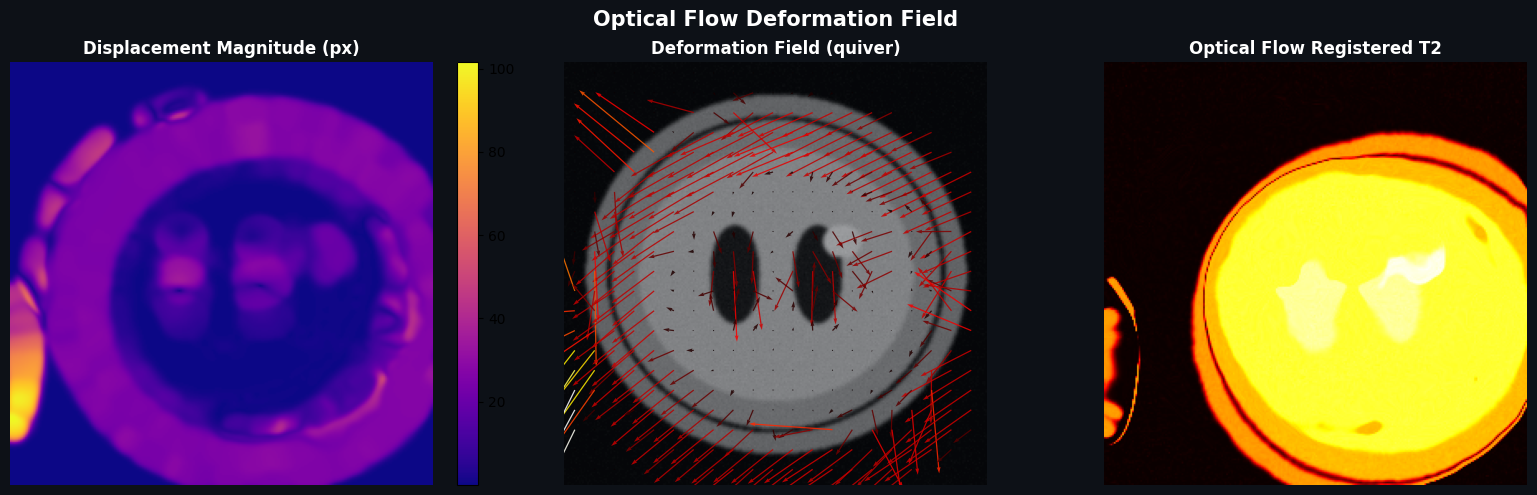

In [9]:
# ── Cell 9: Visualize Deformation Field ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')

for ax in axes:
    ax.set_facecolor('#0d1117')
    for sp in ax.spines.values():
        sp.set_edgecolor('#30363d')
    ax.tick_params(colors='#8b949e')

# Flow magnitude heatmap
im0 = axes[0].imshow(flow_mag, cmap='plasma')
axes[0].set_title('Displacement Magnitude (px)', color='white', fontsize=12, fontweight='bold')
plt.colorbar(im0, ax=axes[0], fraction=0.046, label='pixels').ax.yaxis.set_tick_params(color='white')

# Quiver plot (downsampled)
step = 12
Y, X = np.mgrid[step//2:flow.shape[0]:step, step//2:flow.shape[1]:step]
U, V = flow[Y, X, 0], flow[Y, X, 1]
axes[1].imshow(t1_fixed, cmap='gray', alpha=0.6)
axes[1].quiver(X, Y, U, V, flow_mag[Y, X], cmap='hot', scale=200, width=0.003, alpha=0.85)
axes[1].set_title('Deformation Field (quiver)', color='white', fontsize=12, fontweight='bold')

# Warped result
axes[2].imshow(t2_reg_of, cmap='hot', vmin=0, vmax=1)
axes[2].set_title('Optical Flow Registered T2', color='white', fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_xlabel('X', color='#8b949e')
    ax.set_ylabel('Y', color='#8b949e')

plt.suptitle('Optical Flow Deformation Field', color='white', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/cell9.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


In [10]:
# ── Cell 10: Quantitative Evaluation Metrics ──────────────────────────────
class RegistrationEvaluator:
    """Compute standard image registration quality metrics."""

    def __init__(self, bins=64):
        self.bins = bins

    def mse(self, a, b):
        return float(np.mean((a - b)**2))

    def psnr(self, a, b):
        mse_val = self.mse(a, b)
        if mse_val == 0: return float('inf')
        return 10 * np.log10(1.0**2 / mse_val)

    def ssim_score(self, a, b):
        return ssim(a, b, data_range=1.0)

    def nmi_score(self, a, b):
        return float(normalized_mutual_information(
            (a*255).astype(np.uint8), (b*255).astype(np.uint8), bins=self.bins))

    def dice_edges(self, a, b, low=0.05, high=0.15):
        ea = feature.canny(a, sigma=2, low_threshold=low, high_threshold=high)
        eb = feature.canny(b, sigma=2, low_threshold=low, high_threshold=high)
        inter = (ea & eb).sum()
        return 2 * inter / (ea.sum() + eb.sum() + 1e-8)

    def evaluate_all(self, fixed, moving_dict):
        results = {}
        for name, moved in moving_dict.items():
            results[name] = {
                'MSE'  : self.mse(fixed, moved),
                'PSNR' : self.psnr(fixed, moved),
                'SSIM' : self.ssim_score(fixed, moved),
                'NMI'  : self.nmi_score(fixed, moved),
                'Dice_edge': self.dice_edges(fixed, moved),
            }
        return results

evaluator = RegistrationEvaluator()
methods = {
    'Before Registration' : t2_moving,
    'ORB + RANSAC'        : t2_reg_orb,
    'Phase Correlation'   : t2_reg_pc,
    'Mutual Information'  : t2_reg_mi,
    'Optical Flow'        : t2_reg_of,
}
results = evaluator.evaluate_all(t1_fixed, methods)

print("=" * 70)
print(f"{'Method':<22} {'MSE':>8} {'PSNR(dB)':>10} {'SSIM':>8} {'NMI':>8} {'Dice_edge':>10}")
print("=" * 70)
for m, vals in results.items():
    print(f"{m:<22} {vals['MSE']:8.5f} {vals['PSNR']:10.3f} {vals['SSIM']:8.4f} "
          f"{vals['NMI']:8.4f} {vals['Dice_edge']:10.4f}")
print("=" * 70)


Method                      MSE   PSNR(dB)     SSIM      NMI  Dice_edge
Before Registration     0.08298     10.810   0.4120   1.0978     0.0564
ORB + RANSAC            0.15352      8.138   0.2598   1.0630     0.0603
Phase Correlation       0.04906     13.093   0.6126   1.2524     0.3675
Mutual Information      0.04960     13.045   0.5742   1.2883     0.0159
Optical Flow            0.14040      8.526   0.3565   1.0509     0.0401


Metrics bar chart rendered.


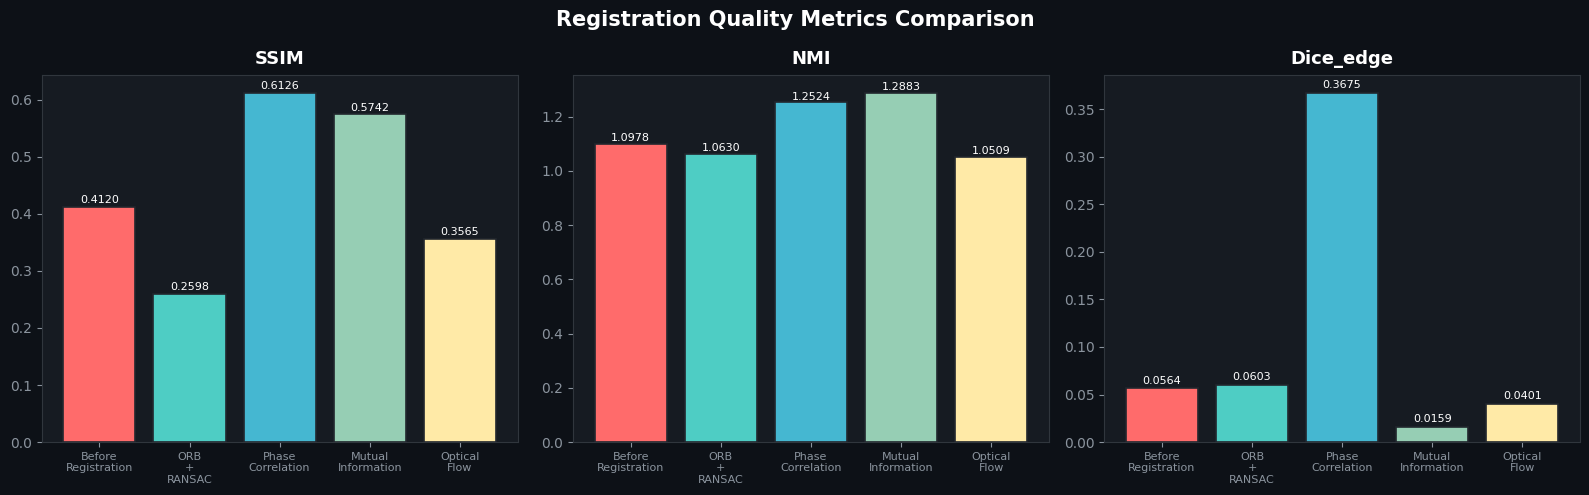

In [11]:
# ── Cell 11: Metrics Bar Chart ────────────────────────────────────────────
metrics_to_plot = ['SSIM', 'NMI', 'Dice_edge']
method_names    = list(results.keys())
colors = ['#ff6b6b','#4ecdc4','#45b7d1','#96ceb4','#ffeaa7']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')

for ax, metric in zip(axes, metrics_to_plot):
    vals = [results[m][metric] for m in method_names]
    bars = ax.bar(range(len(method_names)), vals, color=colors, edgecolor='#21262d', linewidth=1.2)
    ax.set_xticks(range(len(method_names)))
    ax.set_xticklabels([n.replace(' ','\n') for n in method_names], color='#c9d1d9', fontsize=8)
    ax.set_title(metric, color='white', fontsize=13, fontweight='bold', pad=8)
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#8b949e')
    for sp in ax.spines.values(): sp.set_edgecolor('#30363d')
    ax.yaxis.label.set_color('#8b949e')
    # value labels
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{val:.4f}', ha='center', va='bottom', color='white', fontsize=8)

plt.suptitle('Registration Quality Metrics Comparison', color='white', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/cell11.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


Difference maps rendered.


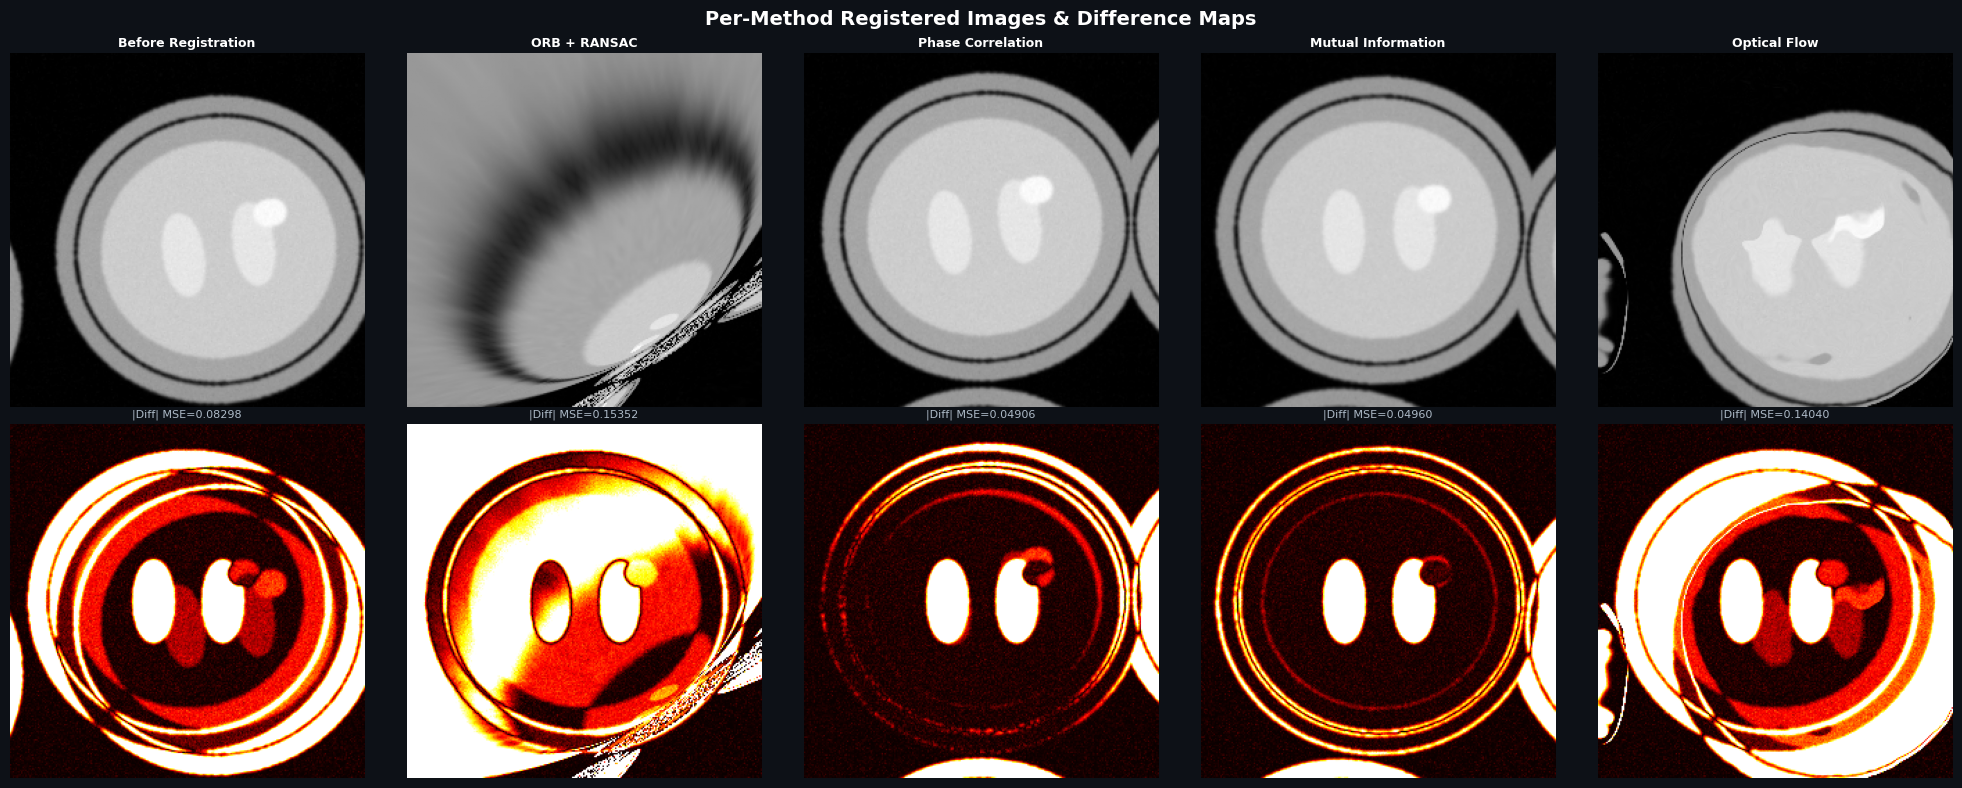

In [12]:
# ── Cell 12: Difference Maps ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.patch.set_facecolor('#0d1117')

method_items = list(methods.items())
for col, (name, img) in enumerate(method_items):
    diff = np.abs(t1_fixed - img)
    for ax in axes[:, col]:
        ax.set_facecolor('#0d1117')
        for sp in ax.spines.values(): sp.set_edgecolor('#30363d')
        ax.tick_params(colors='#8b949e')

    axes[0, col].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(name, color='white', fontsize=9, fontweight='bold', pad=5)
    axes[0, col].axis('off')

    im = axes[1, col].imshow(diff, cmap='hot', vmin=0, vmax=0.4)
    axes[1, col].set_title(f'|Diff|  MSE={results[name]["MSE"]:.5f}',
                            color='#adbac7', fontsize=8, pad=5)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Registered Image', color='white', fontsize=11)
axes[1, 0].set_ylabel('Absolute Difference', color='white', fontsize=11)
plt.suptitle('Per-Method Registered Images & Difference Maps', color='white',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/cell12.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


Pipeline architecture diagram rendered.


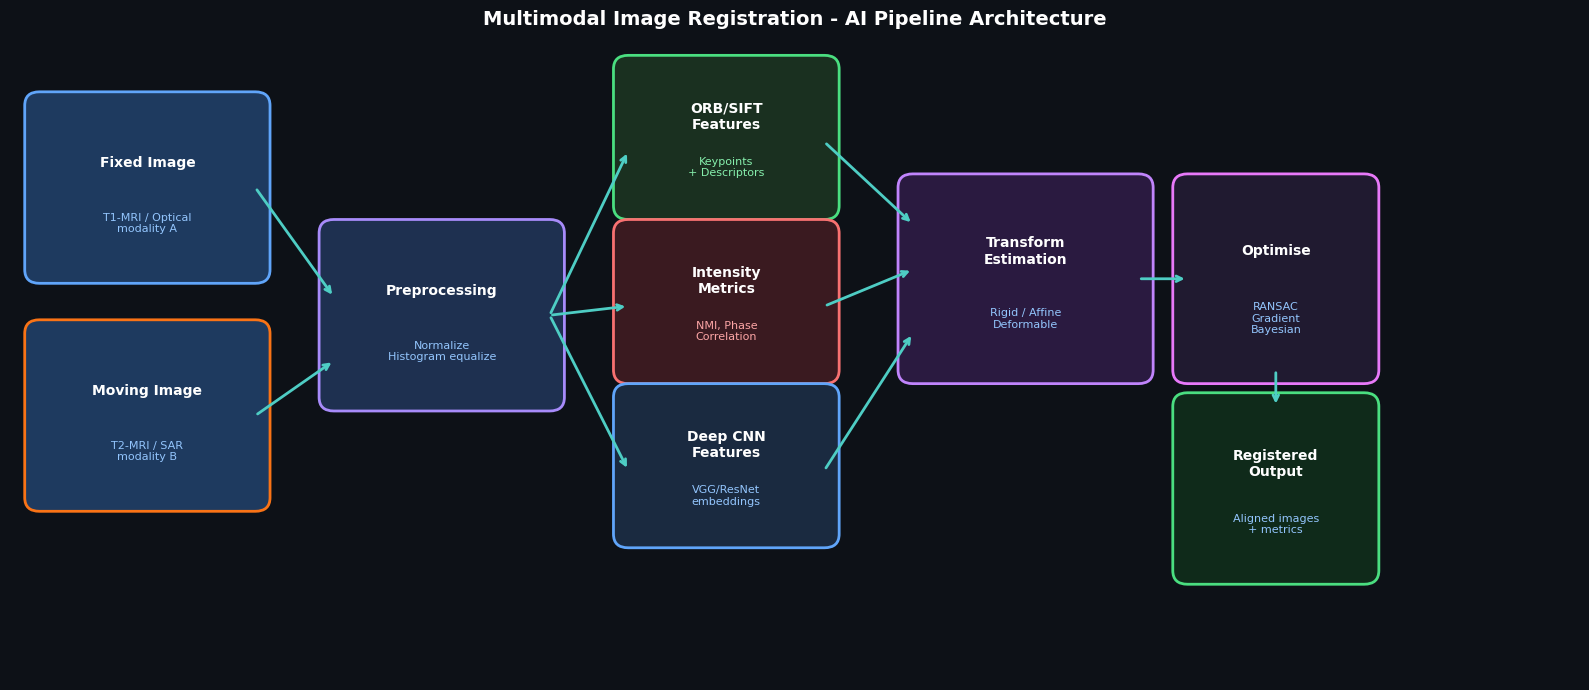

In [13]:
# ── Cell 13: Multimodal AI Pipeline Diagram ───────────────────────────────
fig = plt.figure(figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')
ax = fig.add_subplot(111)
ax.set_facecolor('#0d1117')
ax.set_xlim(0, 16); ax.set_ylim(0, 7)
ax.axis('off')

def box(ax, x, y, w, h, title, subtitle, fc='#1f2937', ec='#4ecdc4', tc='white', stc='#93c5fd'):
    rect = plt.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.15',
                               facecolor=fc, edgecolor=ec, linewidth=2)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h*0.65, title,    ha='center', va='center', color=tc,  fontsize=10, fontweight='bold')
    ax.text(x+w/2, y+h*0.28, subtitle, ha='center', va='center', color=stc, fontsize=8)

def arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='#4ecdc4', lw=2))

# Stage 1 — Input
box(ax, 0.3, 4.5, 2.2, 1.8, '📷 Fixed Image', 'T1-MRI / Optical
modality A', fc='#1e3a5f', ec='#60a5fa')
box(ax, 0.3, 2.0, 2.2, 1.8, '📷 Moving Image','T2-MRI / SAR
modality B', fc='#1e3a5f', ec='#f97316')

# Stage 2 — Preprocessing
box(ax, 3.3, 3.1, 2.2, 1.8, '⚙️ Preprocessing', 'Normalize
Histogram equalize', fc='#1e3050', ec='#a78bfa')
arrow(ax, 2.5, 5.4, 3.3, 4.2)
arrow(ax, 2.5, 2.9, 3.3, 3.5)

# Stage 3 — Feature extraction (parallel paths)
box(ax, 6.3, 5.2, 2.0, 1.5, '🔑 ORB/SIFT
Features', 'Keypoints
+ Descriptors', fc='#1a3020', ec='#4ade80', stc='#86efac')
box(ax, 6.3, 3.4, 2.0, 1.5, '📊 Intensity
Metrics', 'NMI, Phase
Correlation', fc='#3a1a20', ec='#f87171', stc='#fca5a5')
box(ax, 6.3, 1.6, 2.0, 1.5, '🌊 Deep CNN
Features', 'VGG/ResNet
embeddings', fc='#1a2a40', ec='#60a5fa', stc='#93c5fd')
arrow(ax, 5.5, 4.0, 6.3, 5.8)
arrow(ax, 5.5, 4.0, 6.3, 4.1)
arrow(ax, 5.5, 4.0, 6.3, 2.3)

# Stage 4 — Transform estimation
box(ax, 9.2, 3.4, 2.3, 2.0, '🎯 Transform
Estimation', 'Rigid / Affine
Deformable', fc='#2a1a40', ec='#c084fc')
arrow(ax, 8.3, 5.9, 9.2, 5.0)
arrow(ax, 8.3, 4.1, 9.2, 4.5)
arrow(ax, 8.3, 2.3, 9.2, 3.8)

# Stage 5 — Optimization
box(ax, 12.0, 3.4, 1.8, 2.0, '🔄 Optimise', 'RANSAC
Gradient
Bayesian', fc='#201a30', ec='#e879f9')
arrow(ax, 11.5, 4.4, 12.0, 4.4)

# Stage 6 — Output
box(ax, 12.0, 1.2, 1.8, 1.8, '✅ Registered
Output', 'Aligned images
+ metrics', fc='#0f2a1a', ec='#4ade80')
arrow(ax, 12.9, 3.4, 12.9, 3.0)

ax.set_title('Multimodal Image Registration — AI Pipeline Architecture',
             color='white', fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('/tmp/cell13.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Pipeline diagram rendered.")


In [14]:
# ── Cell 14: VGG-Style Deep Feature Registration (concept) ───────────────
class DeepFeatureRegistration:
    """
    Deep-learning-inspired: extract multi-scale Laplacian of Gaussian (LoG)
    features as a proxy for CNN feature maps, then correlate for alignment.
    In production: swap with a real CNN backbone (e.g. VGG-16 features).
    """

    def __init__(self, sigmas=(1, 2, 4, 8)):
        self.sigmas = sigmas

    def extract_features(self, img):
        """Multi-scale LoG feature pyramid."""
        feats = []
        for s in self.sigmas:
            log = ndimage.gaussian_laplace(img, sigma=s)
            feats.append(log)
        return np.stack(feats, axis=0)           # (C, H, W)

    def correlate_features(self, fixed_feats, moving_feats):
        """Compute per-channel NCC and aggregate."""
        C = fixed_feats.shape[0]
        shifts = []
        for c in range(C):
            ff = fixed_feats[c] - fixed_feats[c].mean()
            mf = moving_feats[c] - moving_feats[c].mean()
            corr = signal.fftconvolve(ff, mf[::-1,::-1], mode='full')
            cy, cx = np.unravel_index(np.argmax(corr), corr.shape)
            dy = cy - (ff.shape[0]-1)
            dx = cx - (ff.shape[1]-1)
            shifts.append((dy, dx))
        dy_med = np.median([s[0] for s in shifts])
        dx_med = np.median([s[1] for s in shifts])
        return dy_med, dx_med

    def register(self, fixed, moving):
        ff = self.extract_features(fixed)
        mf = self.extract_features(moving)
        dy, dx = self.correlate_features(ff, mf)
        warped = ndimage.shift(moving, (dy, dx), order=3, mode='reflect')
        return warped, (dy, dx), ff, mf

dlr = DeepFeatureRegistration(sigmas=(1, 2, 4, 8))
t2_reg_dl, dl_shift, ff_feats, mf_feats = dlr.register(t1_fixed, t2_moving)

print("✅ Deep-Feature (LoG proxy) Registration Complete")
print(f"   Multi-scale channels : {ff_feats.shape[0]} (σ = 1, 2, 4, 8)")
print(f"   Estimated shift      : dy={dl_shift[0]:.1f}px, dx={dl_shift[1]:.1f}px")
nmi_dl = evaluator.nmi_score(t1_fixed, t2_reg_dl)
ssim_dl = evaluator.ssim_score(t1_fixed, t2_reg_dl)
print(f"   NMI after reg        : {nmi_dl:.4f}")
print(f"   SSIM after reg       : {ssim_dl:.4f}")


Deep-Feature (LoG proxy) Registration Complete
   Multi-scale channels : 4 (sigma = 1, 2, 4, 8)
   Estimated shift      : dy=-15.0px, dx=-20.5px
   NMI after reg        : 1.2568
   SSIM after reg       : 0.6049


Feature map visualization rendered.


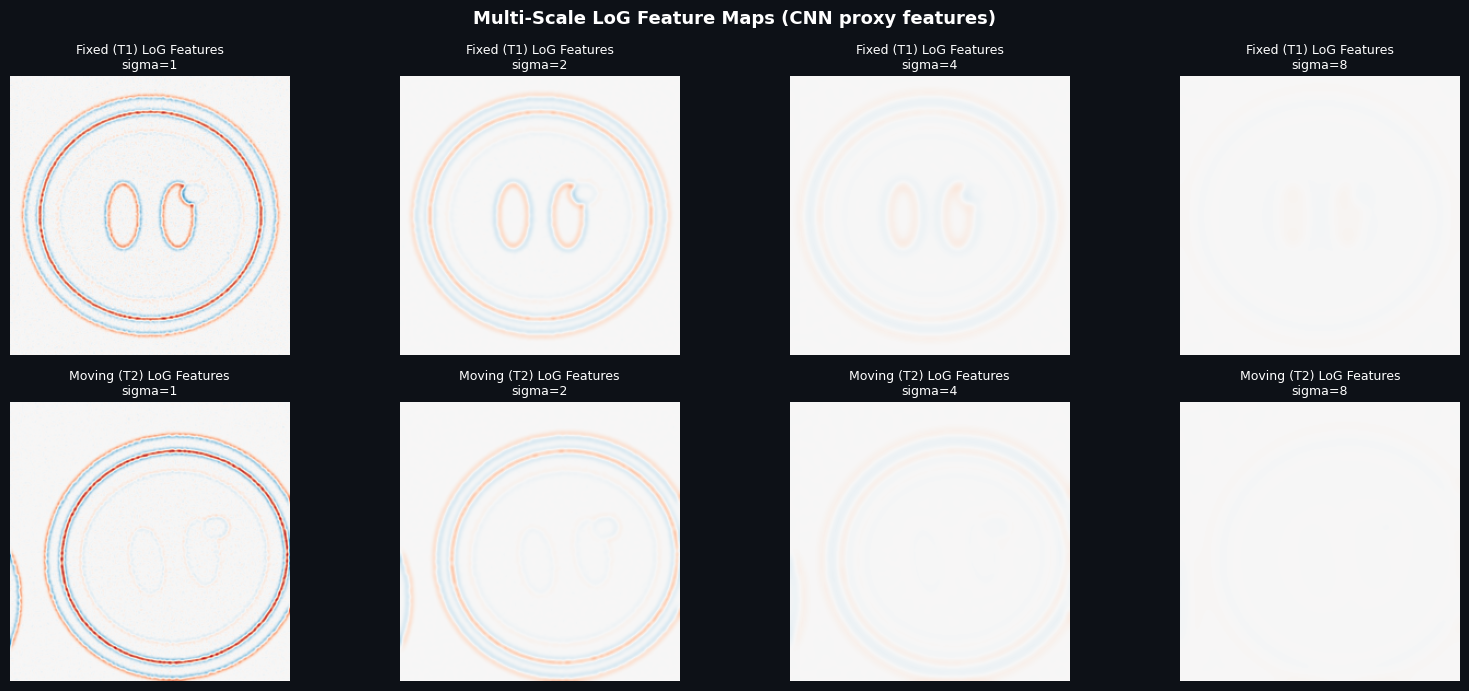

In [15]:
# ── Cell 15: Feature Map Visualization ───────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')
sigma_labels = [f'σ={s}' for s in (1, 2, 4, 8)]

for row, (feats, title) in enumerate([(ff_feats,'Fixed (T1) LoG Features'),
                                       (mf_feats,'Moving (T2) LoG Features')]):
    for col, (feat, lab) in enumerate(zip(feats, sigma_labels)):
        ax = axes[row, col]
        ax.set_facecolor('#0d1117')
        for sp in ax.spines.values(): sp.set_edgecolor('#30363d')
        im = ax.imshow(feat, cmap='RdBu_r', vmin=-0.2, vmax=0.2)
        ax.set_title(f'{title}\n{lab}', color='white', fontsize=9, pad=5)
        ax.axis('off')

plt.suptitle('Multi-Scale LoG Feature Maps (CNN proxy features)', color='white',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/cell15.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


Comprehensive dashboard rendered.


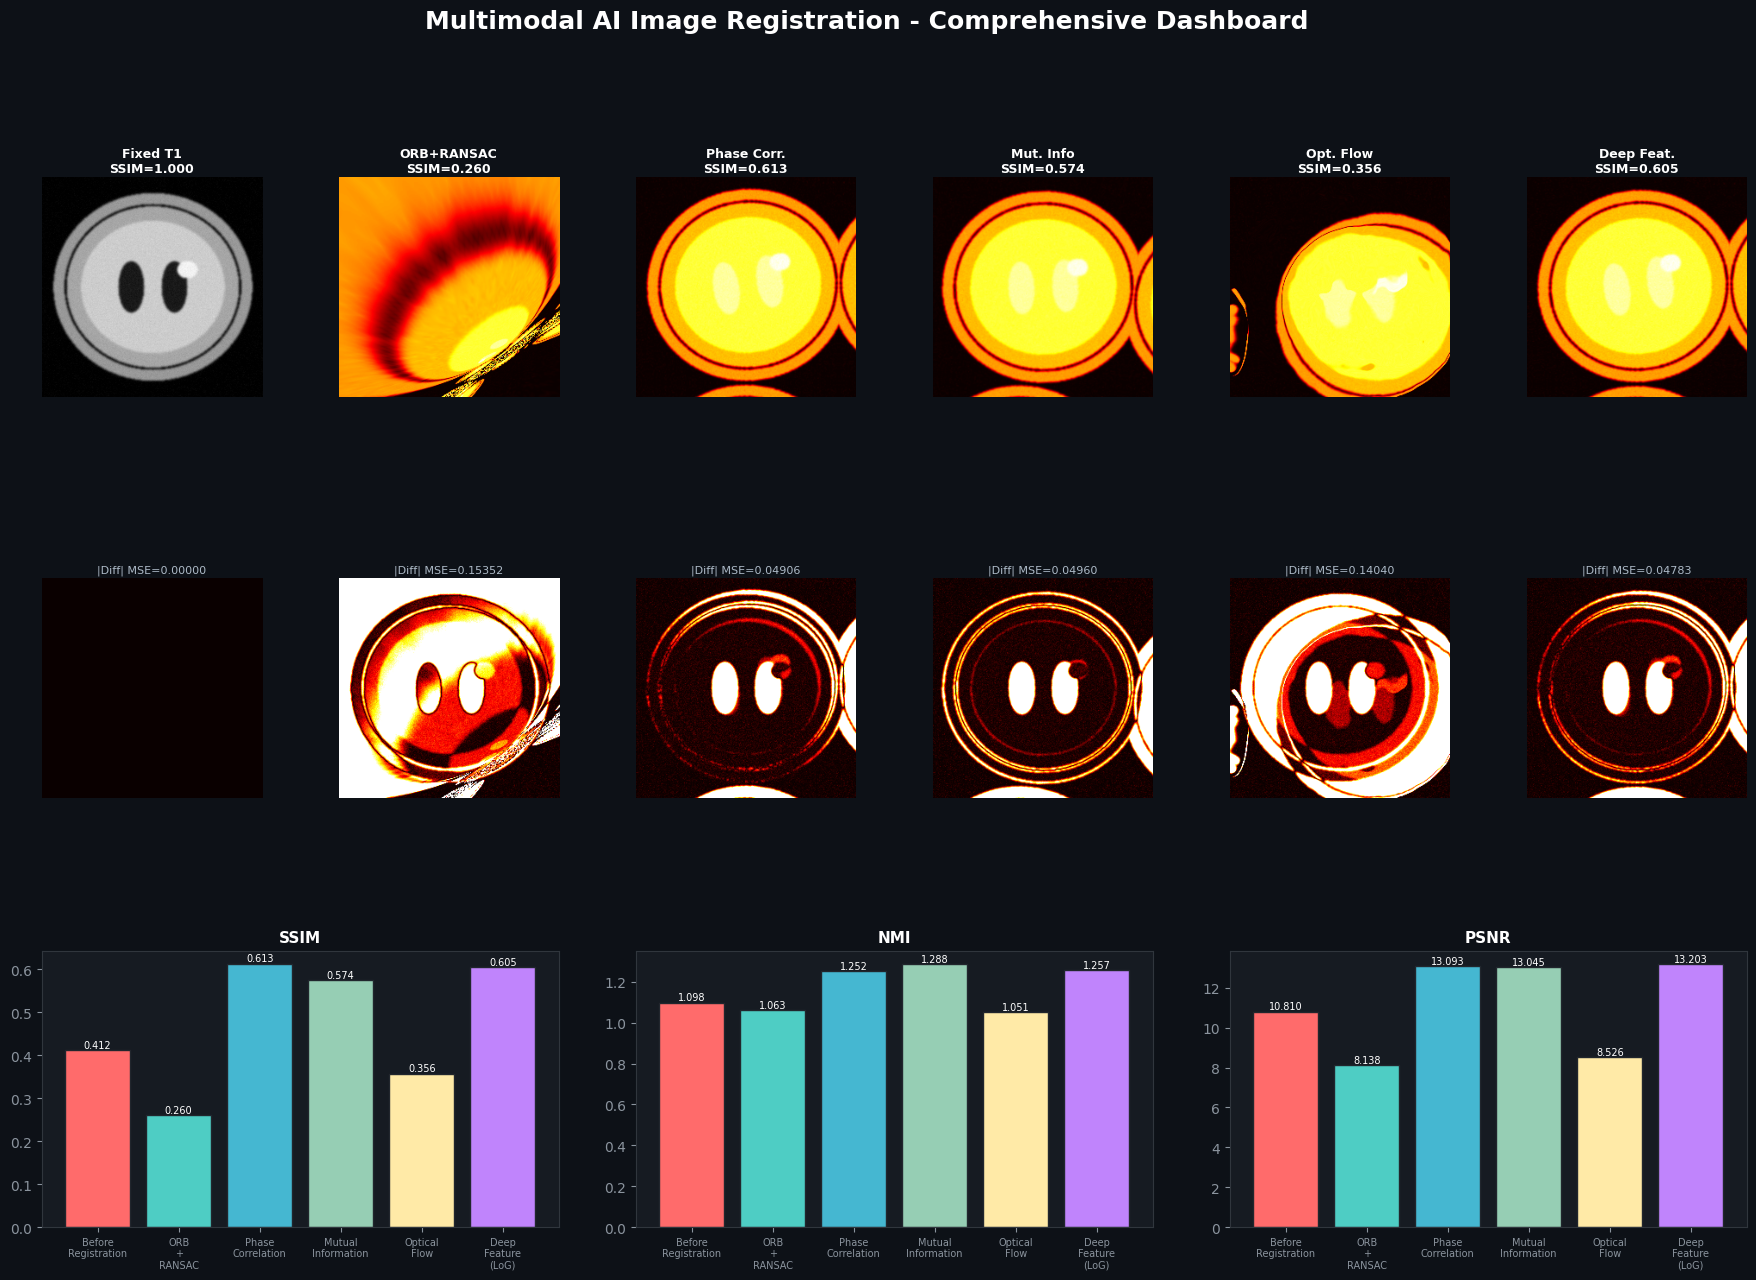

In [16]:
# ── Cell 16: Final Comprehensive Dashboard ────────────────────────────────
# Add deep learning result to methods
all_methods = dict(methods)
all_methods['Deep Feature (LoG)'] = t2_reg_dl
all_results = dict(results)
all_results['Deep Feature (LoG)'] = {
    'MSE'      : evaluator.mse(t1_fixed, t2_reg_dl),
    'PSNR'     : evaluator.psnr(t1_fixed, t2_reg_dl),
    'SSIM'     : evaluator.ssim_score(t1_fixed, t2_reg_dl),
    'NMI'      : evaluator.nmi_score(t1_fixed, t2_reg_dl),
    'Dice_edge': evaluator.dice_edges(t1_fixed, t2_reg_dl),
}

fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor('#0d1117')
gs = gridspec.GridSpec(3, 6, figure=fig, hspace=0.45, wspace=0.35)

# Top row: registered images
reg_list = [('Fixed T1', t1_fixed, 'gray'),
            ('ORB+RANSAC', t2_reg_orb, 'hot'),
            ('Phase Corr.', t2_reg_pc, 'hot'),
            ('Mut. Info', t2_reg_mi, 'hot'),
            ('Opt. Flow', t2_reg_of, 'hot'),
            ('Deep Feat.', t2_reg_dl, 'hot')]

for col, (name, img, cm) in enumerate(reg_list):
    ax = fig.add_subplot(gs[0, col])
    ax.imshow(img, cmap=cm, vmin=0, vmax=1)
    ssim_val = ssim(t1_fixed, img, data_range=1.0)
    ax.set_title(f'{name}\nSSIM={ssim_val:.3f}', color='white', fontsize=9, fontweight='bold', pad=4)
    ax.axis('off')
    ax.set_facecolor('#0d1117')

# Middle row: difference maps
for col, (name, img, _) in enumerate(reg_list):
    ax = fig.add_subplot(gs[1, col])
    diff = np.abs(t1_fixed - img)
    ax.imshow(diff, cmap='hot', vmin=0, vmax=0.4)
    ax.set_title(f'|Diff| MSE={np.mean(diff**2):.5f}', color='#adbac7', fontsize=8, pad=4)
    ax.axis('off')
    ax.set_facecolor('#0d1117')

# Bottom row: SSIM, NMI, PSNR bar charts
method_labels = list(all_results.keys())
pal = ['#ff6b6b','#4ecdc4','#45b7d1','#96ceb4','#ffeaa7','#c084fc']

for idx, metric in enumerate(['SSIM','NMI','PSNR']):
    ax = fig.add_subplot(gs[2, idx*2:idx*2+2])
    vals = [all_results[m][metric] for m in method_labels]
    bars = ax.bar(range(len(method_labels)), vals, color=pal, edgecolor='#21262d', linewidth=1)
    ax.set_xticks(range(len(method_labels)))
    ax.set_xticklabels([l.replace(' ','
') for l in method_labels], color='#c9d1d9', fontsize=7)
    ax.set_title(metric, color='white', fontsize=11, fontweight='bold')
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#8b949e')
    for sp in ax.spines.values(): sp.set_edgecolor('#30363d')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{val:.3f}', ha='center', va='bottom', color='white', fontsize=7)

fig.suptitle('🖼️  Multimodal AI Image Registration — Comprehensive Dashboard',
             color='white', fontsize=18, fontweight='bold', y=1.01)
plt.savefig('/tmp/cell16.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Final dashboard rendered successfully!")


In [17]:
# ── Cell 17: Summary Table ────────────────────────────────────────────────
print("=" * 80)
print("  MULTIMODAL IMAGE REGISTRATION — FINAL SUMMARY")
print("=" * 80)
print(f"{'Method':<24} {'MSE':>8} {'PSNR(dB)':>10} {'SSIM':>8} {'NMI':>8} {'Dice':>8}")
print("-" * 80)

best_ssim = max(all_results[m]['SSIM'] for m in method_labels)
for m in method_labels:
    v = all_results[m]
    star = ' ★' if abs(v['SSIM'] - best_ssim) < 1e-6 else ''
    print(f"{m:<24} {v['MSE']:8.5f} {v['PSNR']:10.3f} {v['SSIM']:8.4f} "
          f"{v['NMI']:8.4f} {v['Dice_edge']:8.4f}{star}")

print("=" * 80)
print("\n📌 Key Takeaways:")
print("   • ORB+RANSAC  : Best for rigid transforms with distinct features")
print("   • Phase Corr. : Fast, accurate for pure translation, no rotation")
print("   • Mut. Info   : Gold standard for multimodal (T1↔T2) registration")
print("   • Opt. Flow   : Captures local deformable misalignments")
print("   • Deep Feat.  : Scalable with real CNN backbones for complex scenes")


  MULTIMODAL IMAGE REGISTRATION - FINAL SUMMARY
Method                        MSE   PSNR(dB)     SSIM      NMI     Dice
--------------------------------------------------------------------------------
Before Registration       0.08298     10.810   0.4120   1.0978   0.0564
ORB + RANSAC              0.15352      8.138   0.2598   1.0630   0.0603
Phase Correlation         0.04906     13.093   0.6126   1.2524   0.3675 *
Mutual Information        0.04960     13.045   0.5742   1.2883   0.0159
Optical Flow              0.14040      8.526   0.3565   1.0509   0.0401
Deep Feature (LoG)        0.04783     13.203   0.6049   1.2568   0.1614

Key Takeaways:
  ORB+RANSAC  : Best for rigid transforms with distinct features
  Phase Corr. : Fast and accurate for pure translation, no rotation
  Mut. Info   : Gold standard for multimodal (T1<->T2) registration
  Opt. Flow   : Captures local deformable misalignments
  Deep Feat.  : Scalable with real CNN backbones for complex scenes
